## Fusion des tables et extraction pour former un dataset .csv

In [2]:
#Connexion (é reéxecuter si conn est close)
import pandas as pd
import mysql.connector

# Connexion à MySQL
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='monmotdepasse',
    database='moodle_dataset',
    connection_timeout=600
)

print("Connexion établie")

Connexion établie


In [7]:
#Requête de fusion et extraction
query = """
SELECT
    logs.userid,
    logs.activity_count,
    logs.login_count,
    logs.resources_viewed,
    COALESCE(DATEDIFF(
        FROM_UNIXTIME((SELECT MAX(timecreated) FROM mdl_logstore_standard_log)),
        FROM_UNIXTIME(inact.last_timeaccess)
    ), 999) AS days_inactive,
    COALESCE(grades.average_grade, 0)         AS average_grade,
    COALESCE(assign.assignments_submitted, 0)  AS assignments_submitted,
    COALESCE(forum.forum_posts, 0)             AS forum_posts,
    COALESCE(compl.completion_rate, 0)         AS completion_rate,
    COALESCE(quiz.quiz_attempts_count, 0)      AS quiz_attempts_count

FROM (
    SELECT
        userid,
        COUNT(*) AS activity_count,
        SUM(CASE WHEN action = 'loggedin' THEN 1 ELSE 0 END) AS login_count,
        SUM(CASE WHEN action = 'viewed'   THEN 1 ELSE 0 END) AS resources_viewed
    FROM mdl_logstore_standard_log
    WHERE userid > 1
      AND action IN ('viewed','submitted','loggedin','graded',
                     'started','ended','searched','clicked',
                     'loggedout','sent','added','joined')
    GROUP BY userid
) logs

LEFT JOIN (
    SELECT userid, MAX(timeaccess) AS last_timeaccess
    FROM mdl_user_lastaccess
    GROUP BY userid
) inact ON logs.userid = inact.userid

LEFT JOIN (
    SELECT userid, AVG(finalgrade) AS average_grade
    FROM mdl_grade_grades
    WHERE finalgrade IS NOT NULL
    GROUP BY userid
) grades ON logs.userid = grades.userid

LEFT JOIN (
    SELECT userid, COUNT(*) AS assignments_submitted
    FROM mdl_assign_submission
    WHERE status = 'submitted'
    GROUP BY userid
) assign ON logs.userid = assign.userid

LEFT JOIN (
    SELECT userid, COUNT(*) AS forum_posts
    FROM mdl_forum_posts
    WHERE deleted = 0
    GROUP BY userid
) forum ON logs.userid = forum.userid

LEFT JOIN (
    SELECT userid,
           AVG(CASE WHEN completionstate = 1 THEN 1.0 ELSE 0.0 END) AS completion_rate
    FROM mdl_course_modules_completion
    GROUP BY userid
) compl ON logs.userid = compl.userid

LEFT JOIN (
    SELECT userid, COUNT(*) AS quiz_attempts_count
    FROM mdl_quiz_attempts
    WHERE state = 'finished'
    GROUP BY userid
) quiz ON logs.userid = quiz.userid
"""

print("Extraction en cours...")
df = pd.read_sql(query, conn)
conn.close()

print(f"Dimensions : {df.shape}")
df.head(10)

Extraction en cours...


C:\Users\miora\AppData\Local\Temp\ipykernel_35200\2525962830.py:75: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Dimensions : (3046, 10)


,userid,activity_count,login_count,resources_viewed,days_inactive,average_grade,assignments_submitted,forum_posts,completion_rate,quiz_attempts_count
0,2,2265,27.0,91.0,1486,0.0,0,0,0.0,0
1,4,6,1.0,4.0,1722,0.0,0,0,0.0,0
2,20,92,7.0,84.0,1522,0.0,0,0,0.0,0
3,23,10,0.0,7.0,999,0.0,0,0,0.0,0
4,27,42,3.0,34.0,1742,0.0,0,0,0.0,0
5,31,61,6.0,54.0,1715,0.0,0,0,0.0,0
6,33,8,1.0,7.0,1708,0.0,0,0,0.0,0
7,35,94,22.0,71.0,980,0.0,0,0,0.5,0
8,42,73,6.0,62.0,1730,0.0,0,0,0.0,0
9,44,30,7.0,18.0,1735,0.0,0,0,0.0,0


In [8]:
df.to_csv('dataset_moodle_features.csv', index=False)
print("CSV sauvegardé")

CSV sauvegardé


## Analyse des données à partir du fichier "dataset_moodle_features.csv"

In [131]:
#Chargement depuis le CSV
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset_moodle_features.csv')

print(f"Dimensions : {df.shape}")
df.head()

Dimensions : (3046, 10)


,userid,activity_count,login_count,resources_viewed,days_inactive,average_grade,assignments_submitted,forum_posts,completion_rate,quiz_attempts_count
0,2,2265,27.0,91.0,1486,0.0,0,0,0.0,0
1,4,6,1.0,4.0,1722,0.0,0,0,0.0,0
2,20,92,7.0,84.0,1522,0.0,0,0,0.0,0
3,23,10,0.0,7.0,999,0.0,0,0,0.0,0
4,27,42,3.0,34.0,1742,0.0,0,0,0.0,0


In [132]:
#Statistiques descriptives pour délimiter le seuil
features = [
    'login_count', 'activity_count', 'resources_viewed',
    'days_inactive', 'average_grade', 'assignments_submitted',
    'forum_posts', 'completion_rate', 'quiz_attempts_count'
]

df[features].describe().round(2)

,login_count,activity_count,resources_viewed,days_inactive,average_grade,assignments_submitted,forum_posts,completion_rate,quiz_attempts_count
count,3046.00,3046.00,3046.00,3046.00,3046.00,3046.00,3046.00,3046.00,3046.00
mean,64.13,476.01,367.89,747.12,6.17,2.12,0.14,0.56,6.98
std,244.29,751.79,543.97,629.58,6.80,3.49,0.61,0.47,12.43
min,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3.00,47.00,36.00,42.00,0.00,0.00,0.00,0.00,0.00
50%,17.00,194.00,159.50,999.00,6.35,0.00,0.00,0.91,1.00
75%,60.75,659.75,528.00,1298.00,10.09,3.00,0.00,1.00,5.00
max,5298.00,13490.00,11286.00,1943.00,31.78,25.00,11.00,1.00,111.00


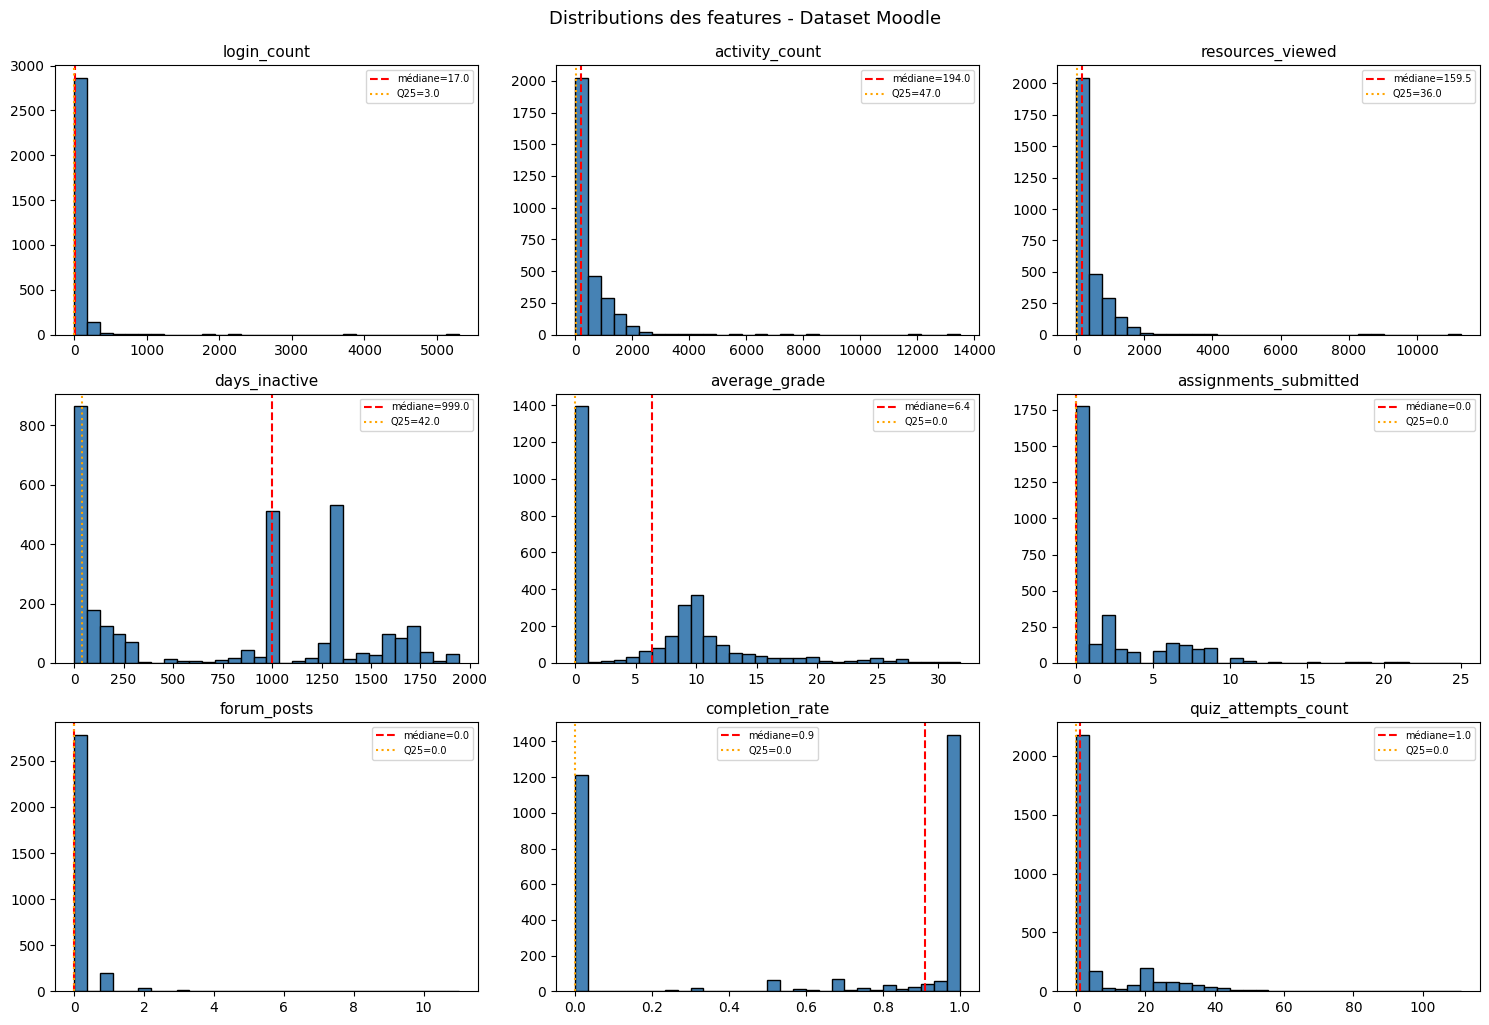

In [133]:
#vérification visuelle 
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].hist(df[col].dropna(), bins=30, 
                 edgecolor='black', color='steelblue')
    axes[i].set_title(col, fontsize=11)
    axes[i].axvline(df[col].median(), color='red', 
                    linestyle='--', linewidth=1.5,
                    label=f'médiane={df[col].median():.1f}')
    axes[i].axvline(df[col].quantile(0.25), color='orange',
                    linestyle=':', linewidth=1.5,
                    label=f'Q25={df[col].quantile(0.25):.1f}')
    axes[i].legend(fontsize=7)

plt.tight_layout()
plt.suptitle("Distributions des features - Dataset Moodle", 
             y=1.02, fontsize=13)
plt.show()

In [134]:
print("Valeurs manquantes par colonne :")
print(df[features].isnull().sum())
print(f"\nTotal lignes : {len(df)}")

Valeurs manquantes par colonne :
login_count              0
activity_count           0
resources_viewed         0
days_inactive            0
average_grade            0
assignments_submitted    0
forum_posts              0
completion_rate          0
quiz_attempts_count      0
dtype: int64

Total lignes : 3046


In [135]:
#Recherce des doublons
doublons = df.duplicated().sum()
print(f"Nombre de doublons : {doublons}")

Nombre de doublons : 0


## Création de la variable cible

In [136]:
#Calcul des seuils à partir des données réelles
q25_login      = df['login_count'].quantile(0.25)   
q25_activity   = df['activity_count'].quantile(0.25)     
q25_resources  = df['resources_viewed'].quantile(0.25)   
q75_inactive   = df['days_inactive'].quantile(0.75)     

print("Seuils retenus :")
print(f"  login_count < {q25_login} : peu connecté")
print(f"  activity_count < {q25_activity} : peu actif")
print(f"  resources_viewed < {q25_resources} : peu de ressources consultées")
print(f"  days_inactive >= 999 : inactif ou absent")
print(f"  average_grade < 1 : pas de note enregistrée")
print(f"  assignments_submitted == 0 : aucun devoir rendu")
print(f"  completion_rate < 0.1 : rien complété")
print(f"  forum_posts == 0 : aucune participation forum")
print(f"  quiz_attempts_count == 0 : aucune tentative quiz")

Seuils retenus :
  login_count < 3.0 : peu connecté
  activity_count < 47.0 : peu actif
  resources_viewed < 36.0 : peu de ressources consultées
  days_inactive >= 999 : inactif ou absent
  average_grade < 1 : pas de note enregistrée
  assignments_submitted == 0 : aucun devoir rendu
  completion_rate < 0.1 : rien complété
  forum_posts == 0 : aucune participation forum
  quiz_attempts_count == 0 : aucune tentative quiz


In [137]:
# Attribution des points de risque
df['pts_connexion']   = (df['login_count'] < 3).astype(int) * 2
df['pts_activite']    = (df['activity_count'] < 47).astype(int) * 2
df['pts_ressources']  = (df['resources_viewed'] < 36).astype(int) * 1
df['pts_inactivite']  = (df['days_inactive'] >= 180).astype(int) * 3
df['pts_notes']       = (df['average_grade'] < 1).astype(int) * 2
df['pts_devoirs']     = (df['assignments_submitted'] == 0).astype(int) * 2
df['pts_completion']  = (df['completion_rate'] < 0.1).astype(int) * 2
df['pts_forum']       = (df['forum_posts'] == 0).astype(int) * 1
df['pts_quiz']        = (df['quiz_attempts_count'] == 0).astype(int) * 1

# Score total
pts_cols = ['pts_connexion', 'pts_activite', 'pts_ressources',
            'pts_inactivite', 'pts_notes', 'pts_devoirs',
            'pts_completion', 'pts_forum', 'pts_quiz']

df['risk_score'] = df[pts_cols].sum(axis=1)

print(f"Score minimum : {df['risk_score'].min()}")
print(f"Score maximum : {df['risk_score'].max()}")
print(f"\nDistribution des scores :")
print(df['risk_score'].value_counts().sort_index())

Score minimum : 0
Score maximum : 16

Distribution des scores :
risk_score
0     248
1     568
2       2
3      54
4     220
5       9
6     329
7     204
8     351
9      71
10     56
11    202
12     37
13     56
14    167
15      2
16    470
Name: count, dtype: int64


In [138]:
SEUIL = 9
df['dropout'] = (df['risk_score'] >= SEUIL).astype(int)

print(f"Répartition finale :")
print(df['dropout'].value_counts())
print(f"\nTaux de décrochage : {df['dropout'].mean():.1%}")

Répartition finale :
dropout
0    1985
1    1061
Name: count, dtype: int64

Taux de décrochage : 34.8%


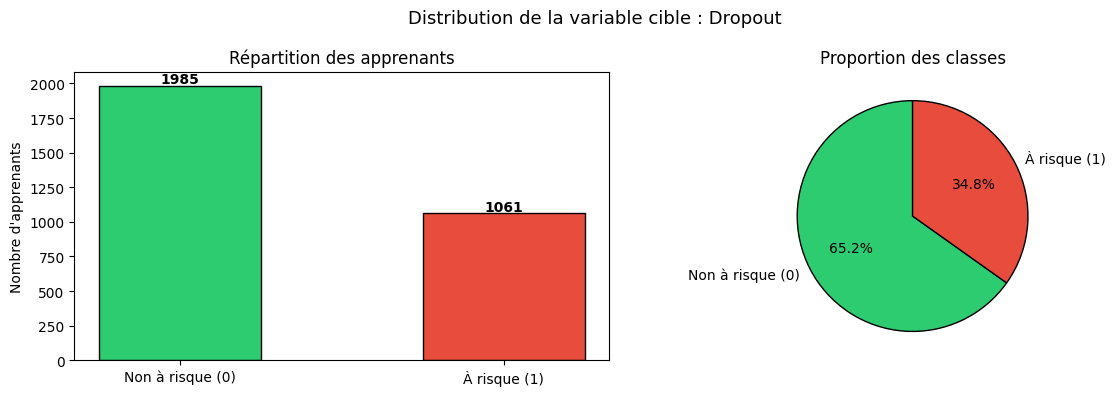

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphe 1 — Barres
labels = ['Non à risque (0)', 'À risque (1)']
values = df['dropout'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Répartition des apprenants')
axes[0].set_ylabel('Nombre d\'apprenants')
for i, v in enumerate(values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

# Graphe 2 — Camembert
axes[1].pie(values, labels=labels, colors=colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Proportion des classes')

plt.suptitle('Distribution de la variable cible : Dropout', fontsize=13)
plt.tight_layout()
plt.show()

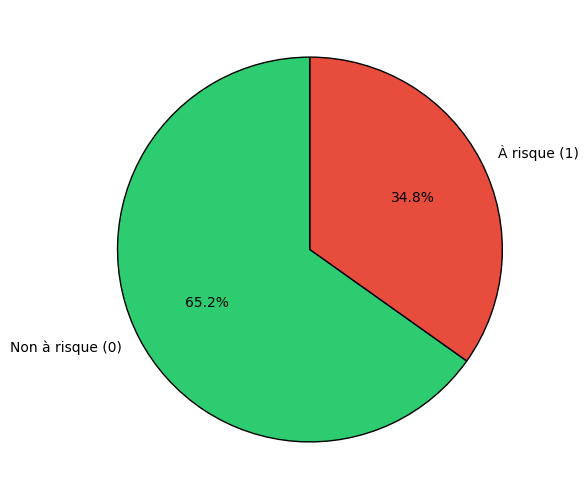

In [155]:
labels = ['Non à risque (0)', 'À risque (1)']
values = df['dropout'].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']

plt.figure(figsize=(6, 6))

plt.pie(
    values,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'black'}
)

plt.tight_layout()
plt.show()

## Comparaison des profils à risque vs non à risque

In [101]:
#Calcul des médianes par groupe
profil = df.groupby('dropout')[features].median()

print("Médianes par groupe :")
print(profil.round(2))

Médianes par groupe :
         login_count  activity_count  resources_viewed  days_inactive  \
dropout                                                                 
0               38.0           447.0             366.0          117.0   
1                2.0            19.0              13.0          999.0   

         average_grade  assignments_submitted  forum_posts  completion_rate  \
dropout                                                                       
0                 9.25                    2.0          0.0              1.0   
1                 0.00                    0.0          0.0              0.0   

         quiz_attempts_count  
dropout                       
0                        3.0  
1                        0.0  


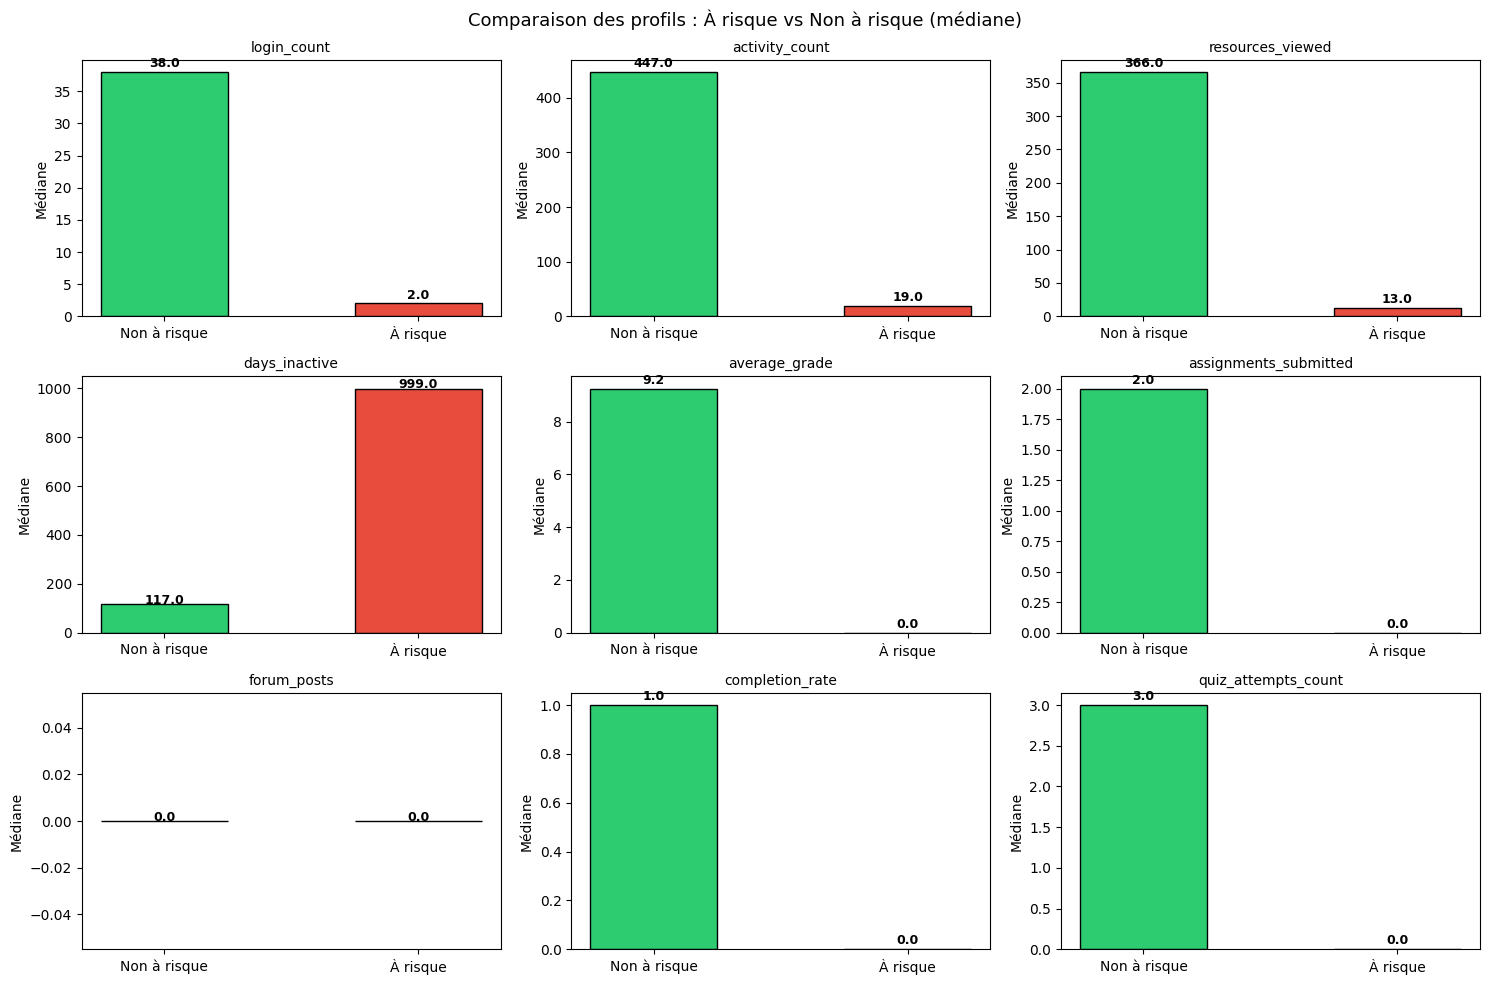

In [102]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    val_0 = df[df['dropout'] == 0][col].median()
    val_1 = df[df['dropout'] == 1][col].median()

    axes[i].bar(['Non à risque', 'À risque'],
                [val_0, val_1],
                color=['#2ecc71', '#e74c3c'],
                edgecolor='black', width=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Médiane')

    # Afficher les valeurs sur les barres
    axes[i].text(0, val_0 + val_0*0.02, f'{val_0:.1f}',
                 ha='center', fontsize=9, fontweight='bold')
    axes[i].text(1, val_1 + val_0*0.02, f'{val_1:.1f}',
                 ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des profils : À risque vs Non à risque (médiane)',
             fontsize=13)
plt.tight_layout()
plt.show()

In [103]:
#Export du dataset final
colonnes_finales = features + ['dropout']
df_final = df[colonnes_finales].copy()

df_final.to_csv('dataset_moodle_final.csv', index=False)

print(f"Dataset exporté")
print(f"Dimensions : {df_final.shape}")

#Rechargement propre pour le pipeline ML
df_ml = pd.read_csv('dataset_moodle_final.csv')

print(f"Dimensions : {df_ml.shape}")
print(f"Colonnes : {list(df_ml.columns)}")
print(f"\nVérification dropout :")
print(df_ml['dropout'].value_counts())
df_ml.head()

Dataset exporté
Dimensions : (3046, 10)
Dimensions : (3046, 10)
Colonnes : ['login_count', 'activity_count', 'resources_viewed', 'days_inactive', 'average_grade', 'assignments_submitted', 'forum_posts', 'completion_rate', 'quiz_attempts_count', 'dropout']

Vérification dropout :
dropout
0    1985
1    1061
Name: count, dtype: int64


,login_count,activity_count,resources_viewed,days_inactive,average_grade,assignments_submitted,forum_posts,completion_rate,quiz_attempts_count,dropout
0,27.0,2265,91.0,1486,0.0,0,0,0.0,0,1
1,1.0,6,4.0,1722,0.0,0,0,0.0,0,1
2,7.0,92,84.0,1522,0.0,0,0,0.0,0,1
3,0.0,10,7.0,999,0.0,0,0,0.0,0,1
4,3.0,42,34.0,1742,0.0,0,0,0.0,0,1


## Séparation features (X) et cible (y)

In [104]:
X = df_ml.drop(columns=['dropout'])
y = df_ml['dropout']

print(f"X (features) : {X.shape}")
print(f"y (cible)     : {y.shape}")
print(f"\nX colonnes : {list(X.columns)}")
print(f"\ny répartition :\n{y.value_counts()}")

X (features) : (3046, 9)
y (cible)     : (3046,)

X colonnes : ['login_count', 'activity_count', 'resources_viewed', 'days_inactive', 'average_grade', 'assignments_submitted', 'forum_posts', 'completion_rate', 'quiz_attempts_count']

y répartition :
dropout
0    1985
1    1061
Name: count, dtype: int64


## Encodage

In [105]:
print("Types des colonnes :")
print(X.dtypes)

Types des colonnes :
login_count              float64
activity_count             int64
resources_viewed         float64
days_inactive              int64
average_grade            float64
assignments_submitted      int64
forum_posts                int64
completion_rate          float64
quiz_attempts_count        int64
dtype: object


## Matrice de corrélation

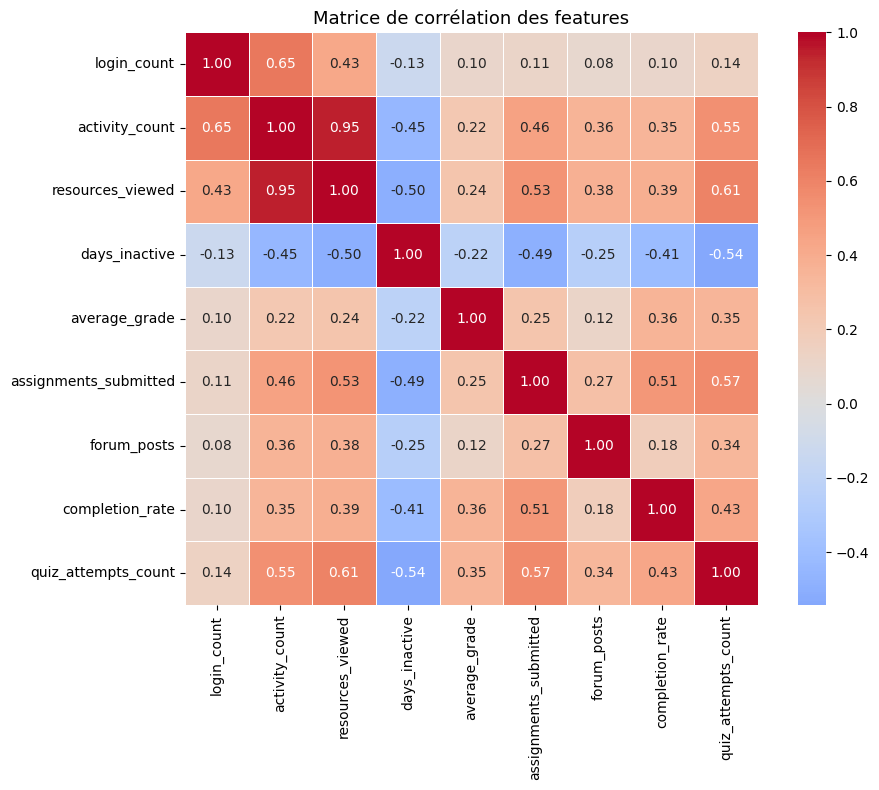

In [106]:
plt.figure(figsize=(10, 8))

correlation = X.corr()

sns.heatmap(correlation,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5)

plt.title('Matrice de corrélation des features', fontsize=13)
plt.tight_layout()
plt.show()

## Séparation train/test

In [107]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train : {X_train.shape[0]} étudiants")
print(f"Test  : {X_test.shape[0]} étudiants")
print(f"\nTaux dropout train : {y_train.mean():.1%}")
print(f"Taux dropout test  : {y_test.mean():.1%}")

Train : 2436 étudiants
Test  : 610 étudiants

Taux dropout train : 34.9%
Taux dropout test  : 34.8%


## Scaling

In [108]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling effectué")
print(f"\nMoyenne avant scaling (login_count) : {X_train['login_count'].mean():.2f}")
print(f"Moyenne après scaling (login_count) : {X_train_scaled[:, 0].mean():.4f}")

Scaling effectué

Moyenne avant scaling (login_count) : 62.46
Moyenne après scaling (login_count) : 0.0000


## Entraînement des 3 modèles

In [109]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)
print("Régression Logistique entraînée ✓")

Régression Logistique entraînée ✓


In [110]:
#Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print("Arbre de décision entraîné ✓")

Arbre de décision entraîné ✓


In [111]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest entraîné ✓")

Random Forest entraîné ✓


In [112]:
#XGBoost
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, 
                    eval_metric='logloss', verbosity=0)
xgb.fit(X_train, y_train)
print("XGBoost entraîné ✓")

XGBoost entraîné ✓


## Planifier prédiction

In [42]:
print(df_ml.columns.tolist())

['login_count', 'activity_count', 'resources_viewed', 'days_inactive', 'average_grade', 'assignments_submitted', 'forum_posts', 'completion_rate', 'quiz_attempts_count', 'dropout']


In [43]:
for idx, row in df_ml.iterrows():
    cursor.execute("""
        INSERT IGNORE INTO student 
        (std_id, nom, email, niveau_risque, probabilite_decrochage, probabilite_non_decrochage, status)
        VALUES (%s, %s, %s, %s, %s, %s, %s)
    """, (
        idx + 1,
        f"Etudiant_{idx + 1}",
        f"etudiant_{idx + 1}@fsts.ac.ma",
        0.0, 0.0, 0.0, 'non à risque'
    ))

conn.commit()
cursor.close()
conn.close()

print(f"{len(df_ml)} étudiants insérés ✓")

3046 étudiants insérés ✓


## Prédiction

In [113]:
# Prédictions sur le jeu de test
y_pred_lr = lr.predict(X_test_scaled)  # → données scalées
y_pred_dt = dt.predict(X_test)         # → données brutes
y_pred_rf = rf.predict(X_test)         # → données brutes

print("Prédictions effectuées")

Prédictions effectuées


In [114]:
#Prédiction XGBoost
y_pred_xgb = xgb.predict(X_test)
print("Prédictions XGBoost ✓")

Prédictions XGBoost ✓


## Calcul des métriques

In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

modeles_resultats = {
    'Régression Logistique': y_pred_lr,
    'Arbre de décision':     y_pred_dt,
    'Random Forest':         y_pred_rf
}

print(f"{'Modèle':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 60)

for nom, y_pred in modeles_resultats.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    print(f"{nom:<25} {acc:>10.1%} {prec:>10.1%} {rec:>10.1%} {f1:>10.1%}")

Modèle                      Accuracy  Precision     Recall         F1
------------------------------------------------------------
Régression Logistique          90.8%      88.6%      84.4%      86.5%
Arbre de décision              99.2%      97.7%     100.0%      98.8%
Random Forest                  99.3%      98.1%     100.0%      99.1%


In [116]:
#Calcul des métriques - 4 modèles
modeles_resultats = {
    'Régression Logistique': y_pred_lr,
    'Arbre de décision':     y_pred_dt,
    'Random Forest':         y_pred_rf,
    'XGBoost':               y_pred_xgb
}

print(f"{'Modèle':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 65)

for nom, y_pred in modeles_resultats.items():
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    print(f"{nom:<25} {acc:>10.1%} {prec:>10.1%} {rec:>10.1%} {f1:>10.1%}")

Modèle                      Accuracy  Precision     Recall         F1
-----------------------------------------------------------------
Régression Logistique          90.8%      88.6%      84.4%      86.5%
Arbre de décision              99.2%      97.7%     100.0%      98.8%
Random Forest                  99.3%      98.1%     100.0%      99.1%
XGBoost                        99.7%      99.1%     100.0%      99.5%


## Analyse train vs test (surapprentissage)

In [117]:
print(f"{'Modèle':<25} {'Train':>8} {'Test':>8} {'Écart':>8} {'Conclusion'}")
print("-" * 65)

donnees = [
    ('Régression Logistique', lr, X_train_scaled, X_test_scaled),
    ('Arbre de décision',     dt, X_train,        X_test),
    ('Random Forest',         rf, X_train,        X_test)
]

for nom, modele, X_tr, X_te in donnees:
    score_train = accuracy_score(y_train, modele.predict(X_tr))
    score_test  = accuracy_score(y_test,  modele.predict(X_te))
    ecart = score_train - score_test

    if ecart < 0.02:
        conclusion = "Pas d'overfitting"
    elif ecart < 0.05:
        conclusion = "Overfitting léger"
    else:
        conclusion = "Overfitting important"

    print(f"{nom:<25} {score_train:>8.1%} {score_test:>8.1%} {ecart:>8.1%} {conclusion}")

Modèle                       Train     Test    Écart Conclusion
-----------------------------------------------------------------
Régression Logistique        91.8%    90.8%     1.0% Pas d'overfitting
Arbre de décision           100.0%    99.2%     0.8% Pas d'overfitting
Random Forest               100.0%    99.3%     0.7% Pas d'overfitting


In [118]:
print(f"{'Modèle':<25} {'Train':>8} {'Test':>8} {'Écart':>8} {'Conclusion'}")
print("-" * 65)

donnees = [
    ('Régression Logistique', lr, X_train_scaled, X_test_scaled),
    ('Arbre de décision',     dt, X_train,        X_test),
    ('Random Forest',         rf, X_train,        X_test),
    ('XGBoost',         xgb, X_train,        X_test)
]

for nom, modele, X_tr, X_te in donnees:
    score_train = accuracy_score(y_train, modele.predict(X_tr))
    score_test  = accuracy_score(y_test,  modele.predict(X_te))
    ecart = score_train - score_test

    if ecart < 0.02:
        conclusion = "Pas d'overfitting"
    elif ecart < 0.05:
        conclusion = "Overfitting léger"
    else:
        conclusion = "Overfitting important"

    print(f"{nom:<25} {score_train:>8.1%} {score_test:>8.1%} {ecart:>8.1%} {conclusion}")

Modèle                       Train     Test    Écart Conclusion
-----------------------------------------------------------------
Régression Logistique        91.8%    90.8%     1.0% Pas d'overfitting
Arbre de décision           100.0%    99.2%     0.8% Pas d'overfitting
Random Forest               100.0%    99.3%     0.7% Pas d'overfitting
XGBoost                     100.0%    99.7%     0.3% Pas d'overfitting


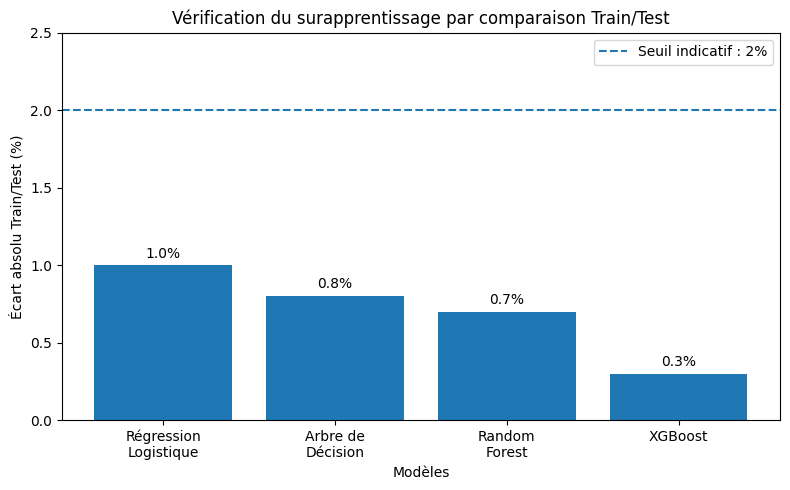

In [120]:
import matplotlib.pyplot as plt
import numpy as np

modeles = [
    'Régression\nLogistique',
    'Arbre de\nDécision',
    'Random\nForest',
    'XGBoost'
]

# Scores en pourcentage
train_scores = np.array([91.8, 100.0, 100.0, 100.0])
test_scores  = np.array([90.8, 99.2, 99.3, 99.7])

# Écart absolu Train/Test
ecarts = np.abs(train_scores - test_scores)

plt.figure(figsize=(8, 5))

bars = plt.bar(modeles, ecarts)

for bar, valeur in zip(bars, ecarts):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        valeur + 0.03,
        f'{valeur:.1f}%',
        ha='center',
        va='bottom'
    )

plt.axhline(y=2, linestyle='--', label='Seuil indicatif : 2%')

plt.ylabel("Écart absolu Train/Test (%)")
plt.xlabel("Modèles")
plt.title("Vérification du surapprentissage par comparaison Train/Test")
plt.ylim(0, 2.5)
plt.legend()

plt.tight_layout()
plt.show()

## Matrice de confusion

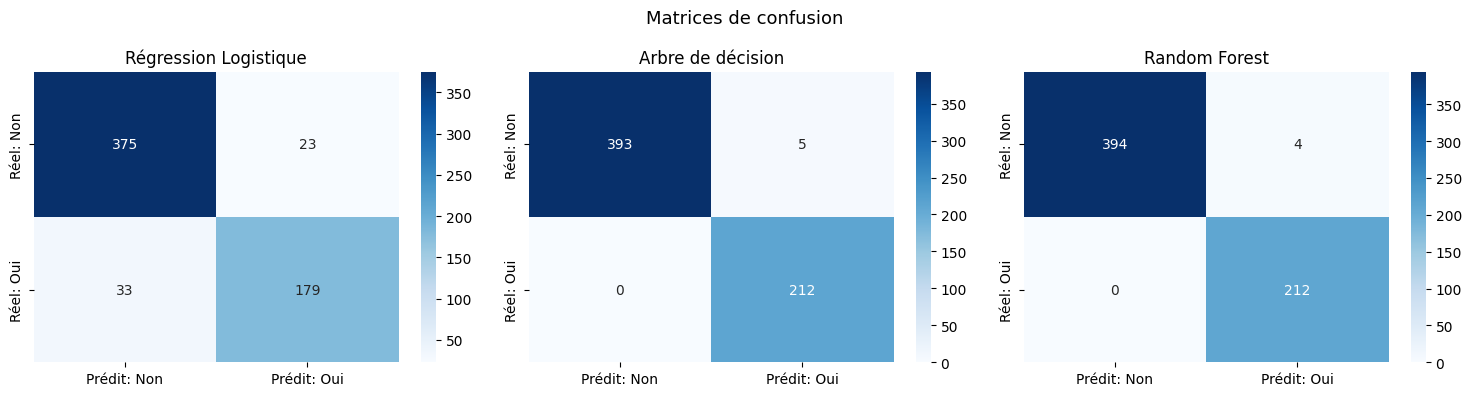

In [121]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

donnees_confusion = [
    ('Régression Logistique', y_pred_lr),
    ('Arbre de décision',     y_pred_dt),
    ('Random Forest',         y_pred_rf)
]

for ax, (nom, y_pred) in zip(axes, donnees_confusion):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prédit: Non', 'Prédit: Oui'],
                yticklabels=['Réel: Non', 'Réel: Oui'],
                ax=ax)
    ax.set_title(nom)

plt.suptitle('Matrices de confusion', fontsize=13)
plt.tight_layout()
plt.show()

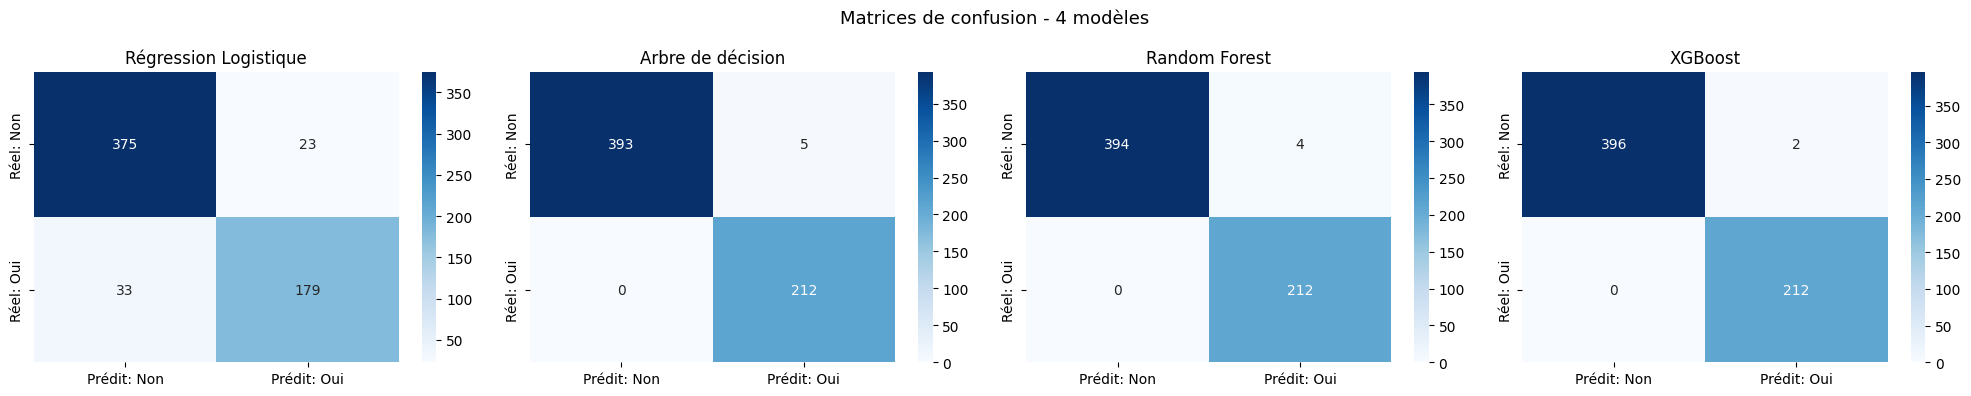

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

donnees_confusion = [
    ('Régression Logistique', y_pred_lr),
    ('Arbre de décision',     y_pred_dt),
    ('Random Forest',         y_pred_rf),
    ('XGBoost',               y_pred_xgb)
]

for ax, (nom, y_pred) in zip(axes, donnees_confusion):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Prédit: Non', 'Prédit: Oui'],
                yticklabels=['Réel: Non', 'Réel: Oui'],
                ax=ax)
    ax.set_title(nom)

plt.suptitle('Matrices de confusion - 4 modèles', fontsize=13)
plt.tight_layout()
plt.show()

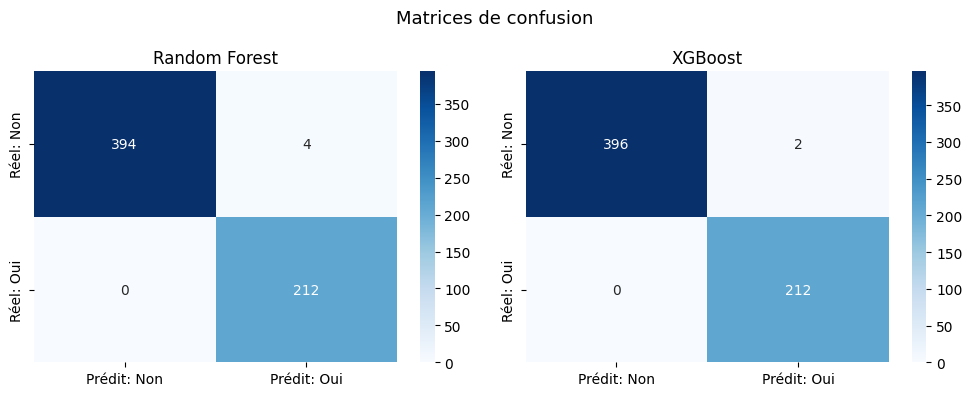

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

donnees_confusion = [
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for ax, (nom, y_pred) in zip(axes, donnees_confusion):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Prédit: Non', 'Prédit: Oui'],
        yticklabels=['Réel: Non', 'Réel: Oui'],
        ax=ax
    )

    ax.set_title(nom)

plt.suptitle('Matrices de confusion', fontsize=13)
plt.tight_layout()
plt.show()

## Comparaison visuelle des métriques

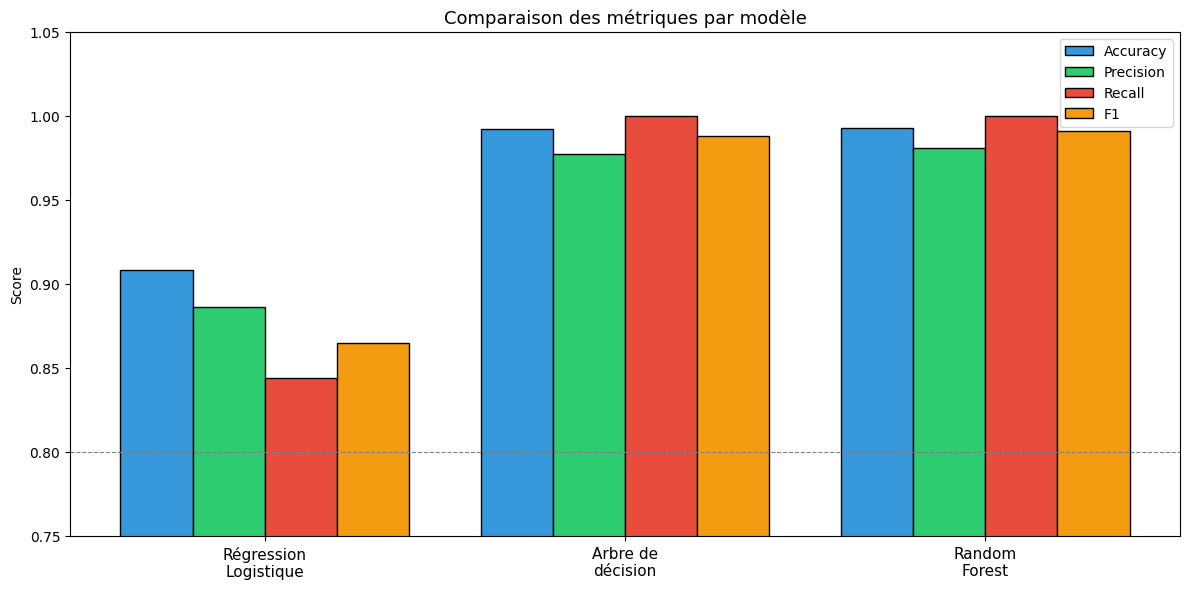

In [123]:
import numpy as np

modeles_noms = ['Régression\nLogistique', 'Arbre de\ndécision', 'Random\nForest']

accuracy  = [0.908, 0.992, 0.993]
precision = [0.886, 0.977, 0.981]
recall    = [0.844, 1.000, 1.000]
f1        = [0.865, 0.988, 0.991]

x = np.arange(len(modeles_noms))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color='#3498db', edgecolor='black')
ax.bar(x - 0.5*width, precision, width, label='Precision', color='#2ecc71', edgecolor='black')
ax.bar(x + 0.5*width, recall,    width, label='Recall',    color='#e74c3c', edgecolor='black')
ax.bar(x + 1.5*width, f1,        width, label='F1',        color='#f39c12', edgecolor='black')

ax.set_ylim(0.75, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(modeles_noms, fontsize=11)
ax.set_ylabel('Score')
ax.set_title('Comparaison des métriques par modèle', fontsize=13)
ax.legend()
ax.axhline(y=0.80, color='gray', linestyle='--', linewidth=0.8, label='Seuil 80%')

plt.tight_layout()
plt.show()

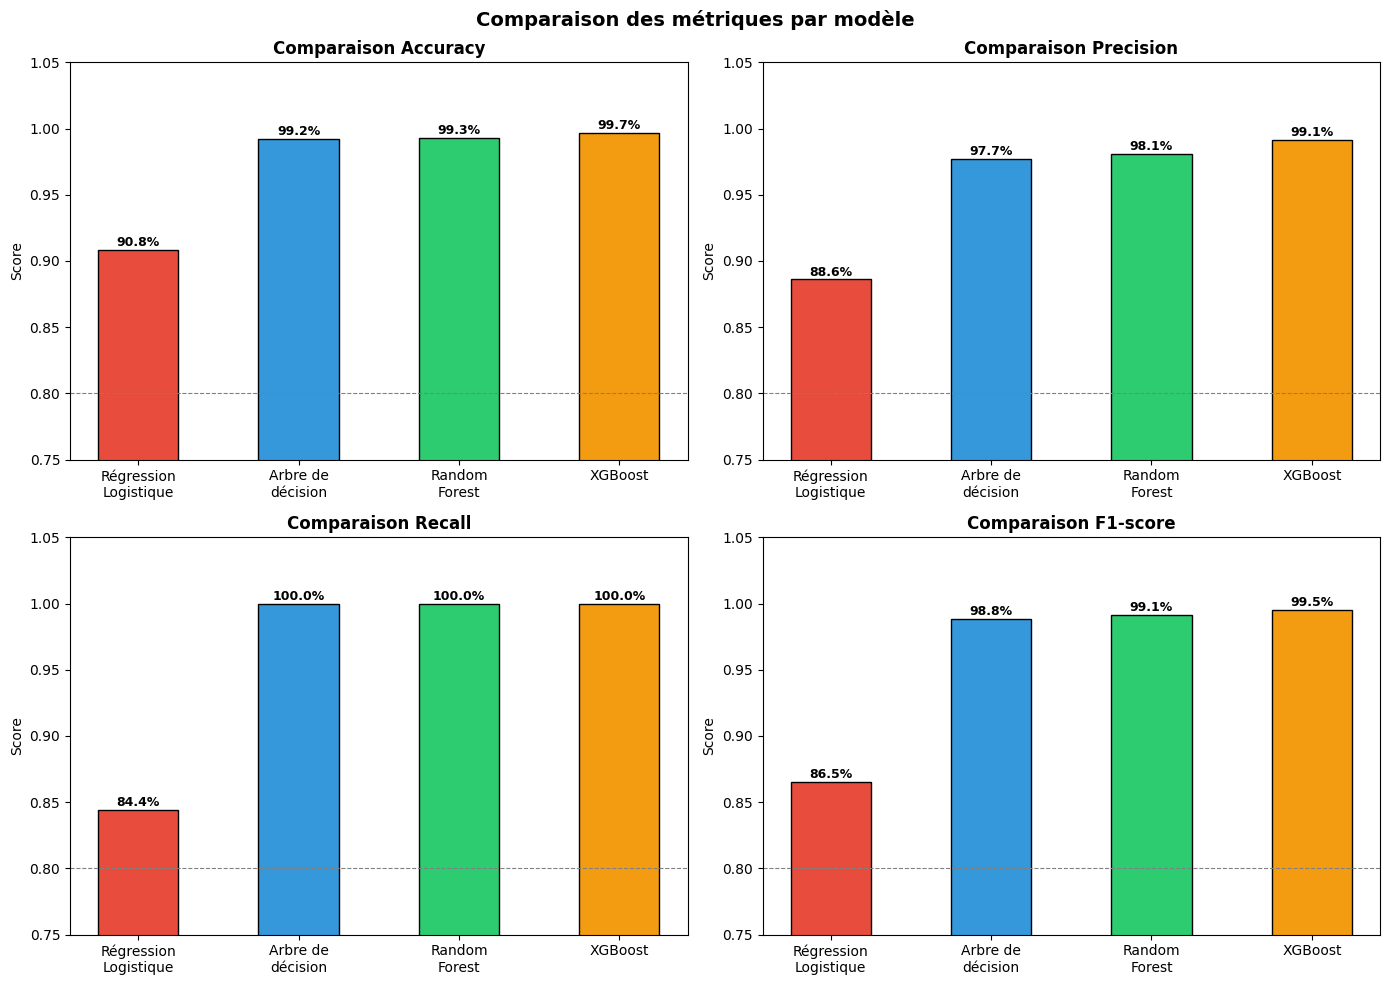

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

modeles_noms = ['Régression\nLogistique', 'Arbre de\ndécision', 
                'Random\nForest', 'XGBoost']

accuracy  = [0.908, 0.992, 0.993, 0.997]
precision = [0.886, 0.977, 0.981, 0.991]
recall    = [0.844, 1.000, 1.000, 1.000]
f1        = [0.865, 0.988, 0.991, 0.995]

couleurs = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

donnees = [
    (axes[0,0], accuracy,  'Accuracy',  'Comparaison Accuracy'),
    (axes[0,1], precision, 'Precision', 'Comparaison Precision'),
    (axes[1,0], recall,    'Recall',    'Comparaison Recall'),
    (axes[1,1], f1,        'F1-score',  'Comparaison F1-score'),
]

for ax, valeurs, label, titre in donnees:
    bars = ax.bar(modeles_noms, valeurs, color=couleurs, edgecolor='black', width=0.5)
    ax.set_ylim(0.75, 1.05)
    ax.set_title(titre, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.axhline(y=0.80, color='gray', linestyle='--', linewidth=0.8)
    for bar, val in zip(bars, valeurs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{val:.1%}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Comparaison des métriques par modèle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Importance des features (Random Forest)

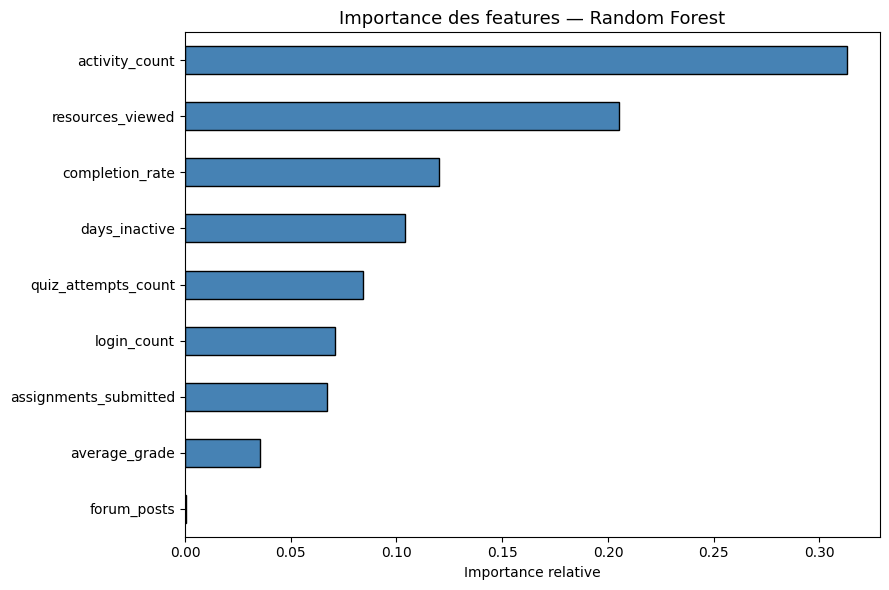


Valeurs exactes :
activity_count           0.3130
resources_viewed         0.2052
completion_rate          0.1199
days_inactive            0.1038
quiz_attempts_count      0.0840
login_count              0.0711
assignments_submitted    0.0670
average_grade            0.0353
forum_posts              0.0006
dtype: float64


In [125]:
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title("Importance des features — Random Forest", fontsize=13)
plt.xlabel("Importance relative")
plt.tight_layout()
plt.show()

print("\nValeurs exactes :")
print(importances.sort_values(ascending=False).round(4))

## Importance des features (XGBoost)

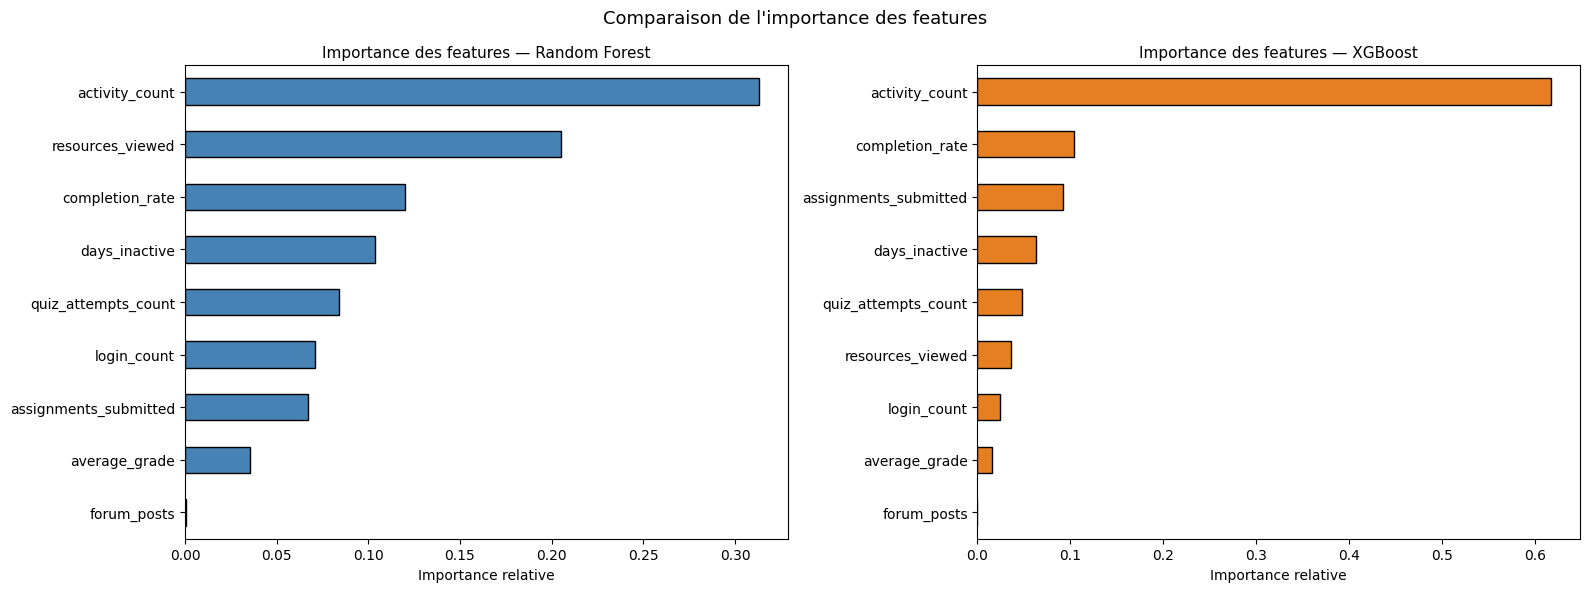

In [126]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest
importances_rf = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=True)

importances_rf.plot(kind='barh', color='steelblue', 
                    edgecolor='black', ax=axes[0])
axes[0].set_title("Importance des features — Random Forest", fontsize=11)
axes[0].set_xlabel("Importance relative")

# XGBoost
importances_xgb = pd.Series(
    xgb.feature_importances_,
    index=features
).sort_values(ascending=True)

importances_xgb.plot(kind='barh', color='#e67e22', 
                     edgecolor='black', ax=axes[1])
axes[1].set_title("Importance des features — XGBoost", fontsize=11)
axes[1].set_xlabel("Importance relative")

plt.suptitle("Comparaison de l'importance des features", fontsize=13)
plt.tight_layout()
plt.show()

### Sauvegarde uniquement Random Forest, le modèle retenu

In [127]:
import joblib

joblib.dump(xgb, 'model.pkl')
print("model.pkl sauvegardé ")

model.pkl sauvegardé 


In [128]:
#Sauvegarde la liste exacte des features dans le bon ordre
joblib.dump(features, 'features.pkl')
print("features.pkl sauvegardé")
print(f"Features : {features}")

features.pkl sauvegardé
Features : ['login_count', 'activity_count', 'resources_viewed', 'days_inactive', 'average_grade', 'assignments_submitted', 'forum_posts', 'completion_rate', 'quiz_attempts_count']
